The goal of this EDA is surface level data analysis, with a focus on churn distribution, and price sensitivity.

- is there a correlation between price/power usage, and churn?
- any noticeable patterns among inactive accounts?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(color_codes=True)

client_data = pd.read_csv('client_data.csv')
price_data = pd.read_csv('price_data.csv')

## Initial EDA

In [2]:
print(client_data.info())
print(price_data.info())
display(client_data.describe())
display(price_data.describe())
#print(client_data['id'].nunique())
#print(client_data['id'].count())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


- client_data has some pretty extreme outlier values in a number of columns, where the maximum value exceeds the 3rd quartile by a coefficient of 10 in some cases such as ['margin_net_pow_ele', 'imp_cons', 'cons_last_month', 'forecast_cons_12m', etc.]. These outliers will create a difficult environment for accurate model training, and will be dealt with accordingly.

- price_data distributions aren't raising any suspicions at first glance.

In [3]:
print(client_data['churn'].value_counts())
print(f'\nPercentage of active customers: {client_data['churn'].value_counts(normalize=True)[0] * 100:.2f}%')
print(f'Percentage of churned customers: {client_data['churn'].value_counts(normalize=True)[1] * 100:.2f}%')

churn
0    13187
1     1419
Name: count, dtype: int64

Percentage of active customers: 90.28%
Percentage of churned customers: 9.72%


- There are no duplicate customer ID's, **14606 unique values**
- **13187 active** (90.28%) (churn = 0), **1419 inactive** (9.72%) (churn = 1)

## Consumption

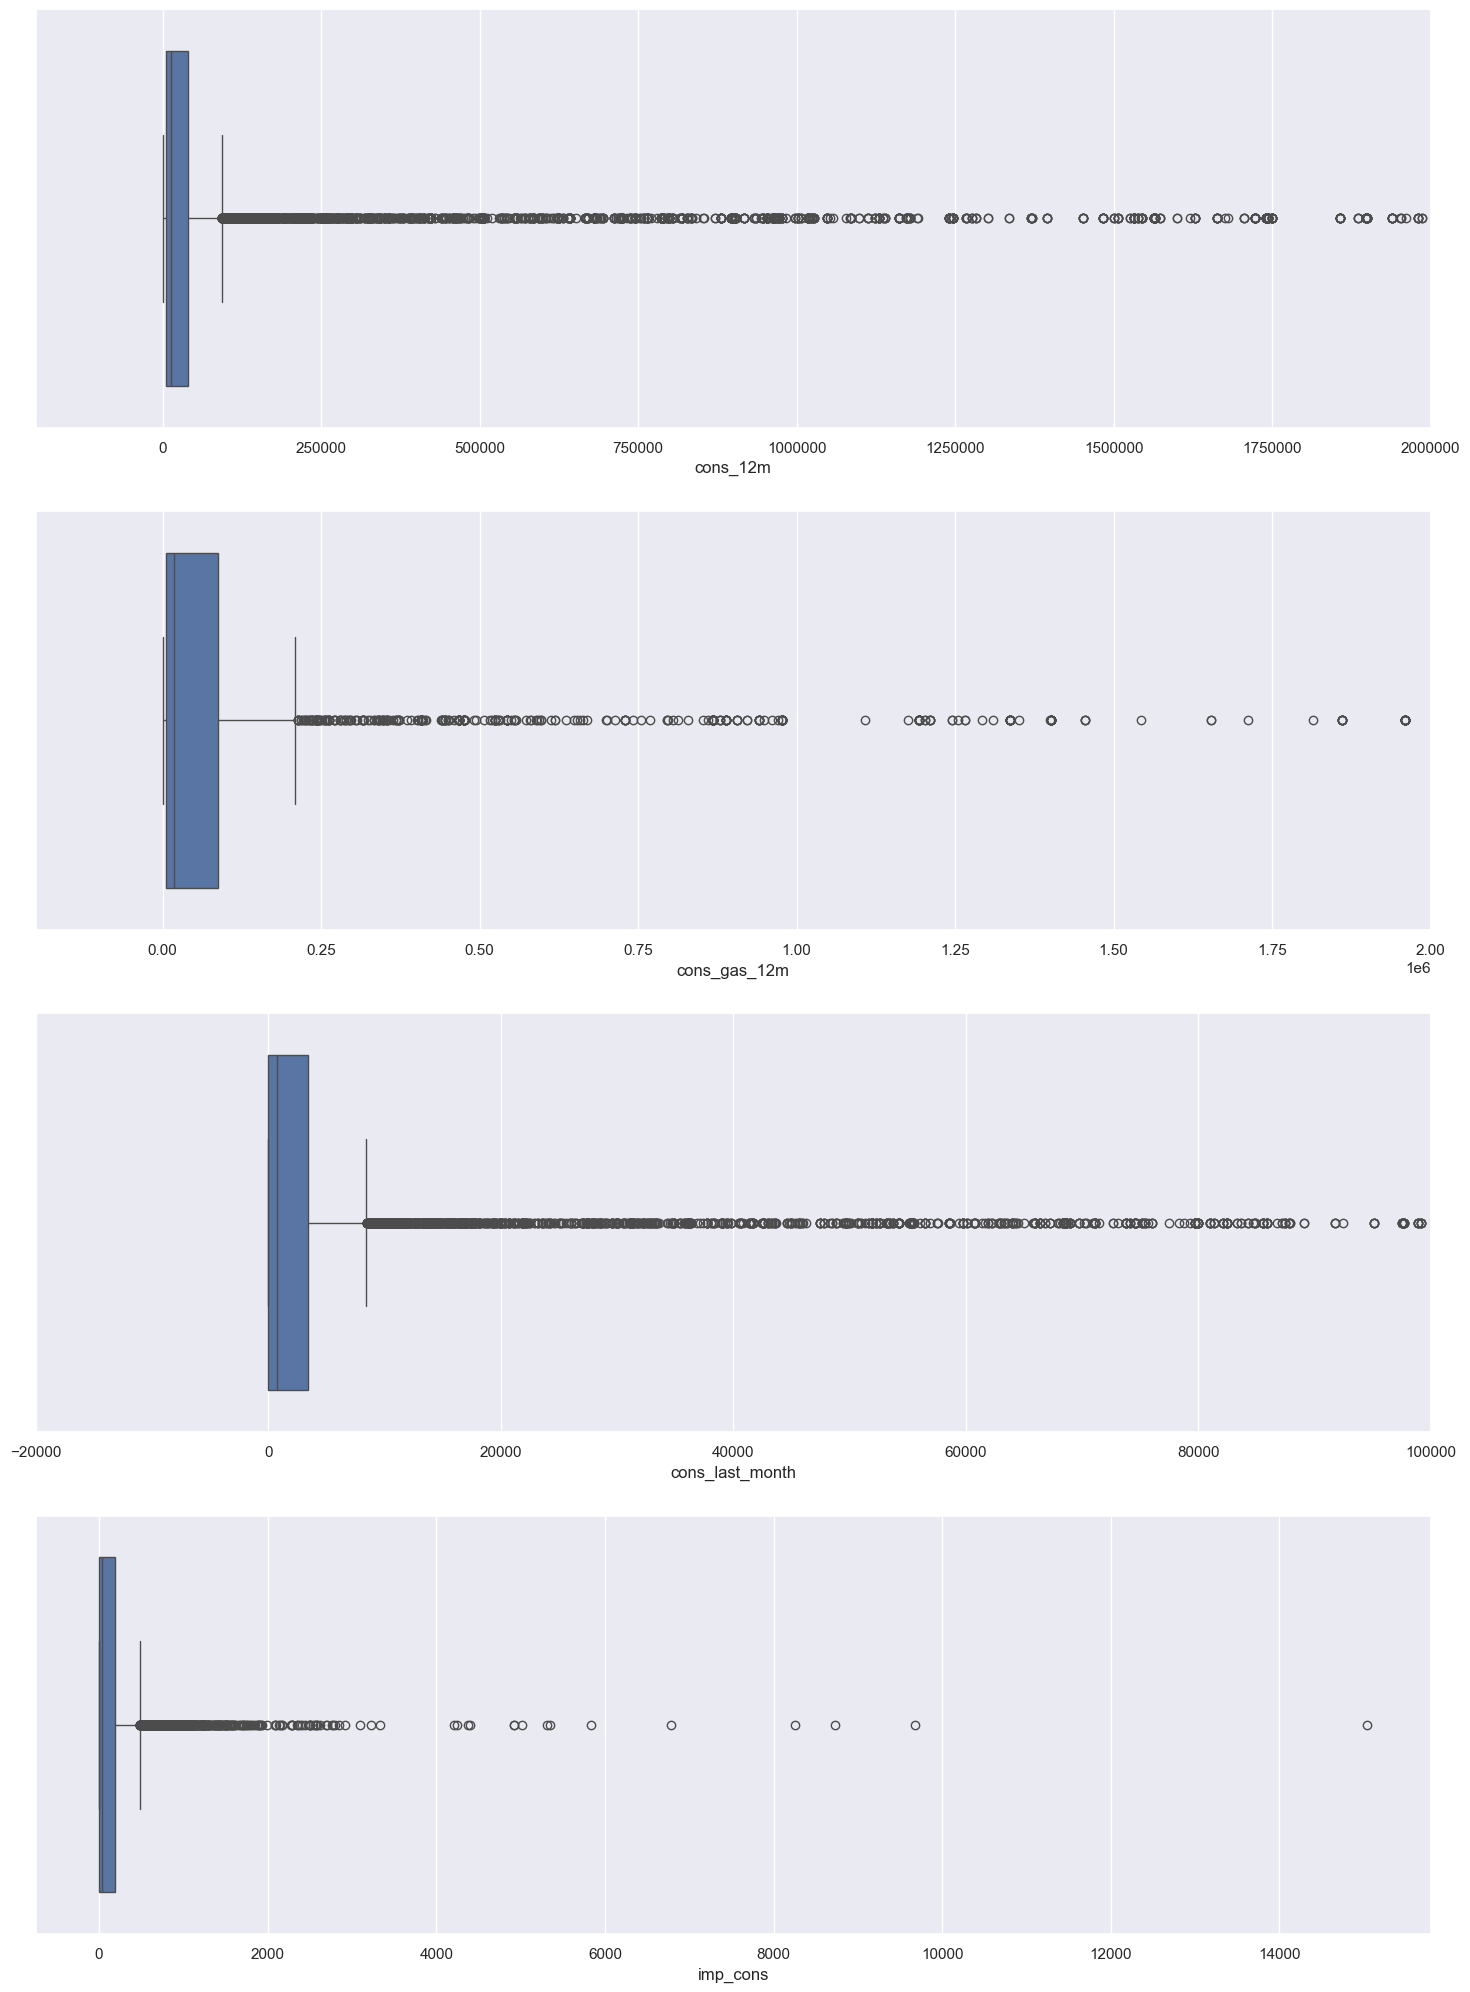

In [4]:
consumption = client_data[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

sns.boxplot(consumption['cons_12m'], ax=axs[0], orient='h')
sns.boxplot(consumption[consumption['has_gas'] == 't']['cons_gas_12m'], ax=axs[1], orient='h')
sns.boxplot(consumption['cons_last_month'], ax=axs[2], orient='h')
sns.boxplot(consumption['imp_cons'], ax=axs[3], orient='h')

for ax in axs:
    ax.ticklabel_format(style='plain', axis='x')
    axs[0].set_xlim(-200000, 2000000)
    axs[1].set_xlim(-200000, 2000000)
    axs[2].set_xlim(-20000, 100000)
    plt.show()

- As stated previously, we have many outliers within columns concerning consumption. These anomalies skew our data and create an unstable environment for predictive modeling.

# Sales

In [5]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_='upper right'):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind='bar',
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

In [6]:
channel = client_data[['id', 'channel_sales', 'churn']]
channel = channel.groupby([channel['channel_sales'], channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

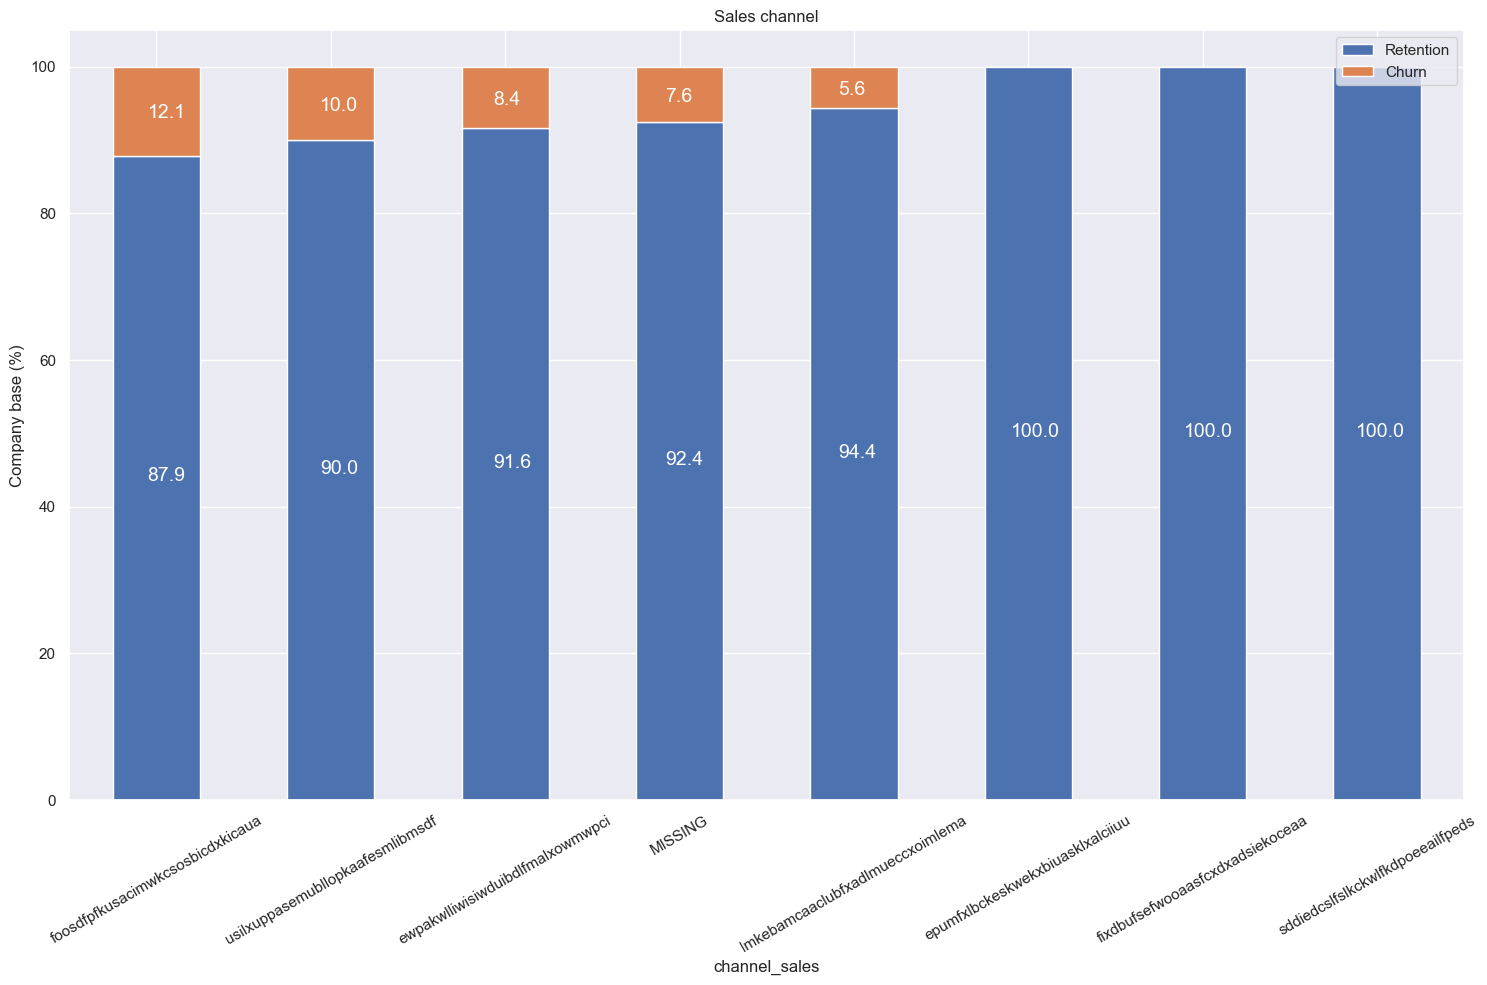

In [7]:
plot_stacked_bars(channel_churn, 'Sales channel', rot_=30)

- only 5 out of the 8 sales channels contain instances of churn, with 'MISSING' representing the absence of a specific channel.

# Forecast

In [8]:
def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distribution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

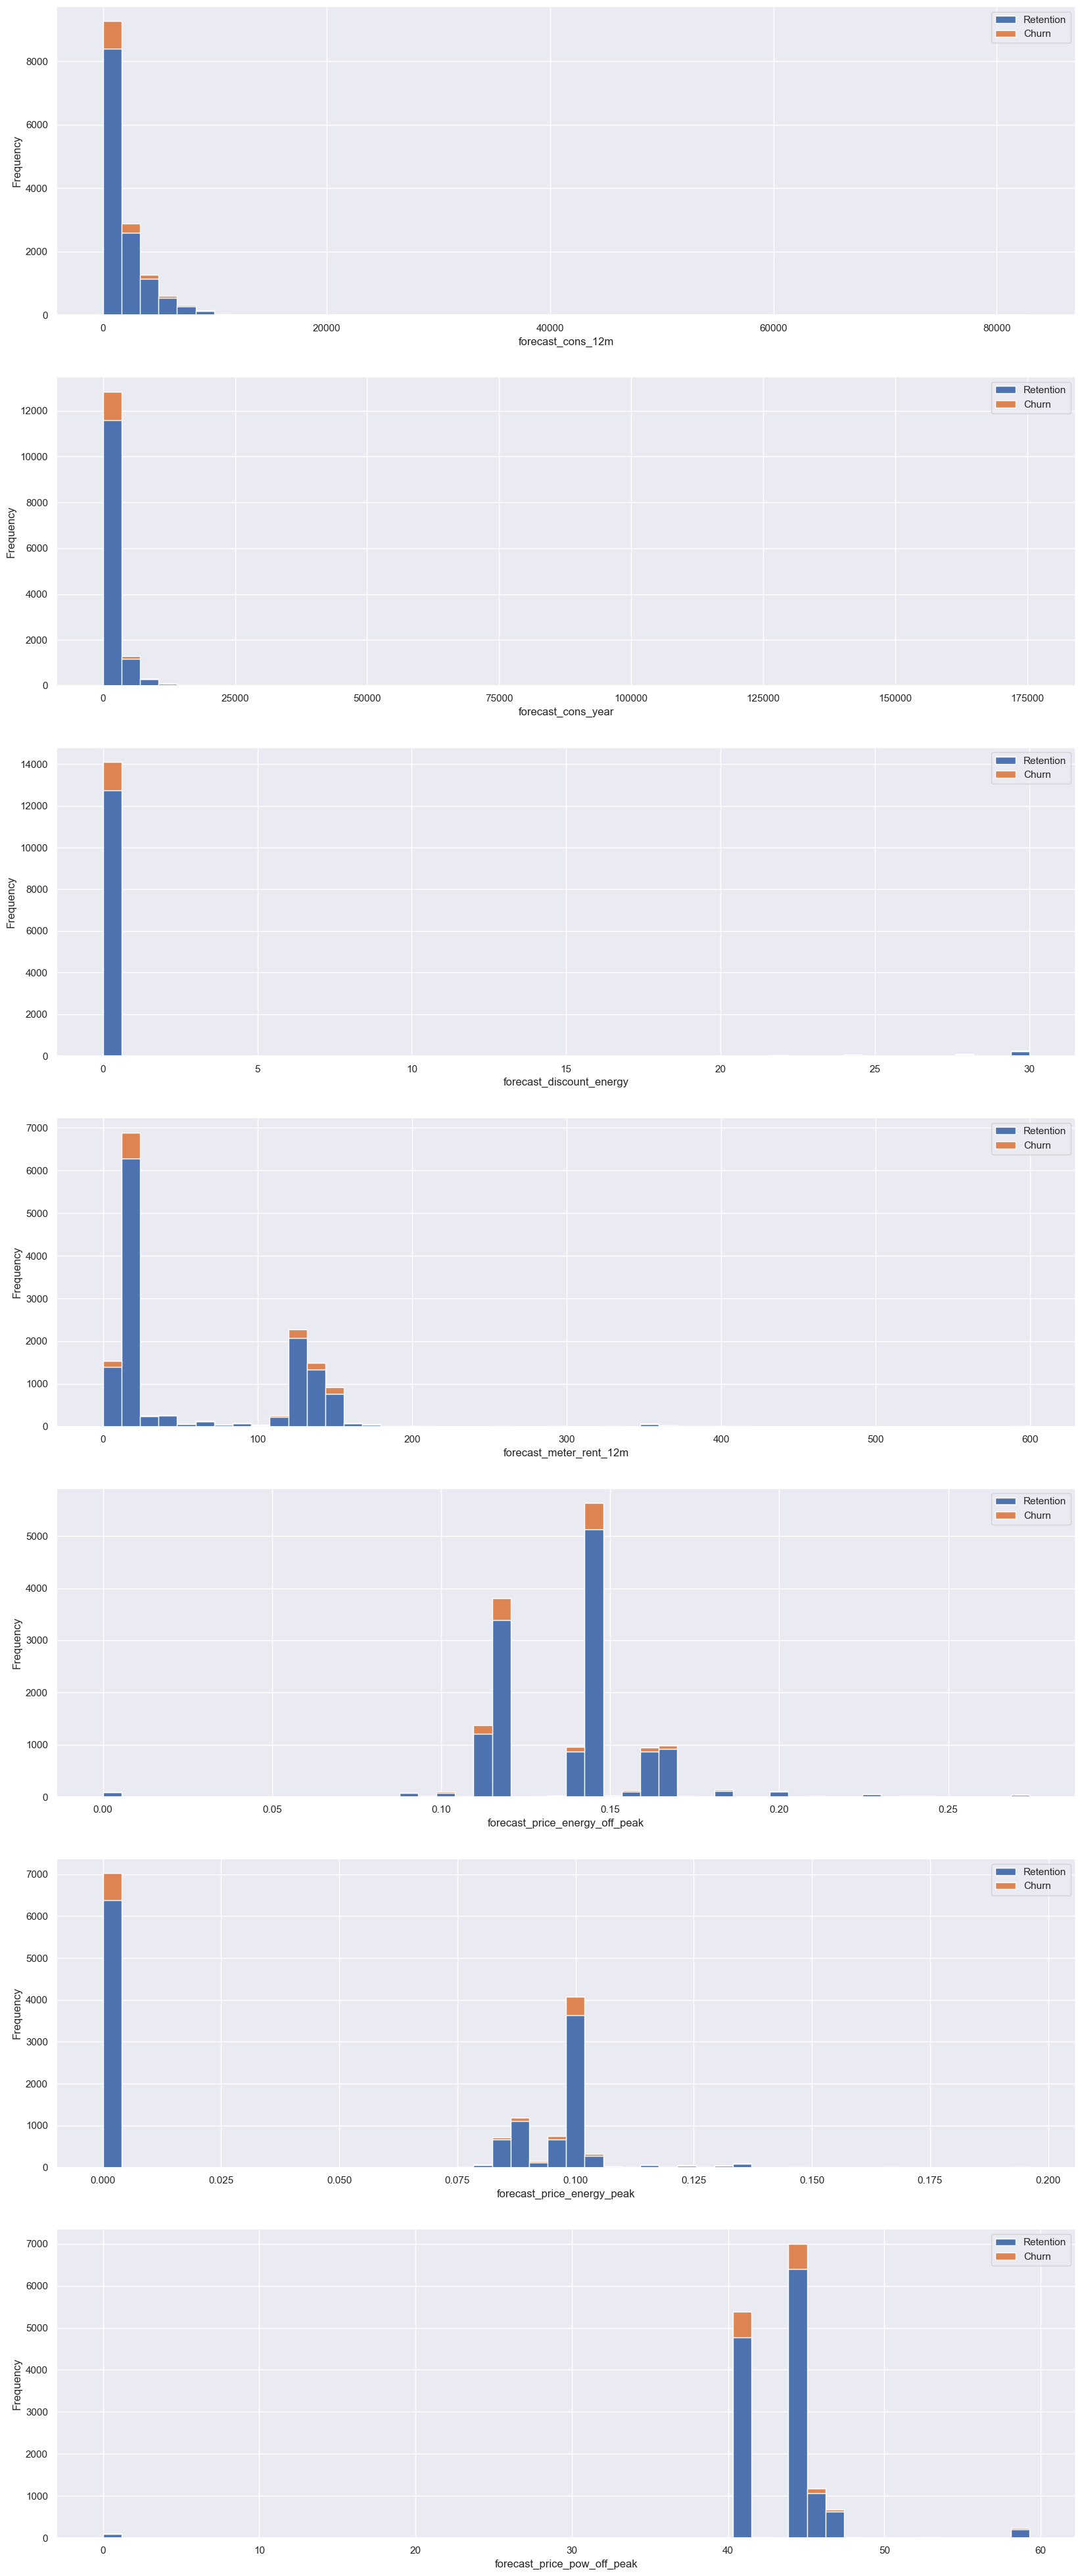

In [9]:
forecast = client_data[["id", "forecast_cons_12m", "forecast_cons_year","forecast_discount_energy",
                        "forecast_meter_rent_12m", "forecast_price_energy_off_peak","forecast_price_energy_peak",
                        "forecast_price_pow_off_peak","churn"]]

fig, axs = plt.subplots(nrows=7, figsize=(20, 50))

plot_distribution(client_data, "forecast_cons_12m", axs[0])
plot_distribution(client_data, "forecast_cons_year", axs[1])
plot_distribution(client_data, "forecast_discount_energy", axs[2])
plot_distribution(client_data, "forecast_meter_rent_12m", axs[3])
plot_distribution(client_data, "forecast_price_energy_off_peak", axs[4])
plot_distribution(client_data, "forecast_price_energy_peak", axs[5])
plot_distribution(client_data, "forecast_price_pow_off_peak", axs[6])

- the forecast variable distributions are highly positively skewed, with many long tails indicating far reaching outliers.

# Contract Type (gas)

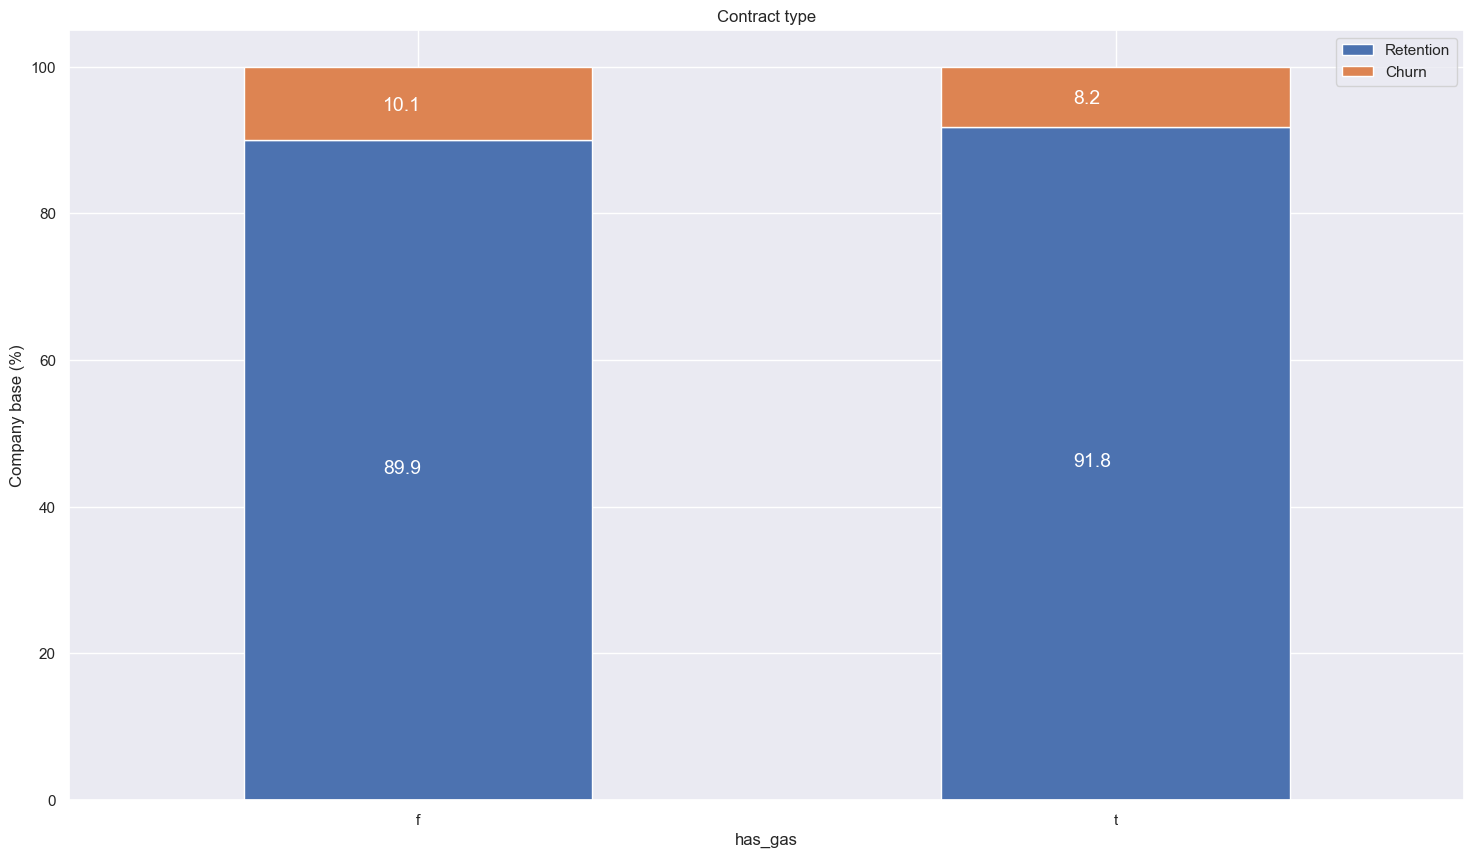

In [ ]:
contract_type = client_data[['id', 'has_gas', 'churn']]
contract_type = contract_type.groupby([contract_type['has_gas'], contract_type['churn']])['id'].count().unstack(level=1).fillna(0)
contract_churn = (contract_type.div(contract_type.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

plot_stacked_bars(contract_churn, 'Contract Type', rot_=0)

# Margins

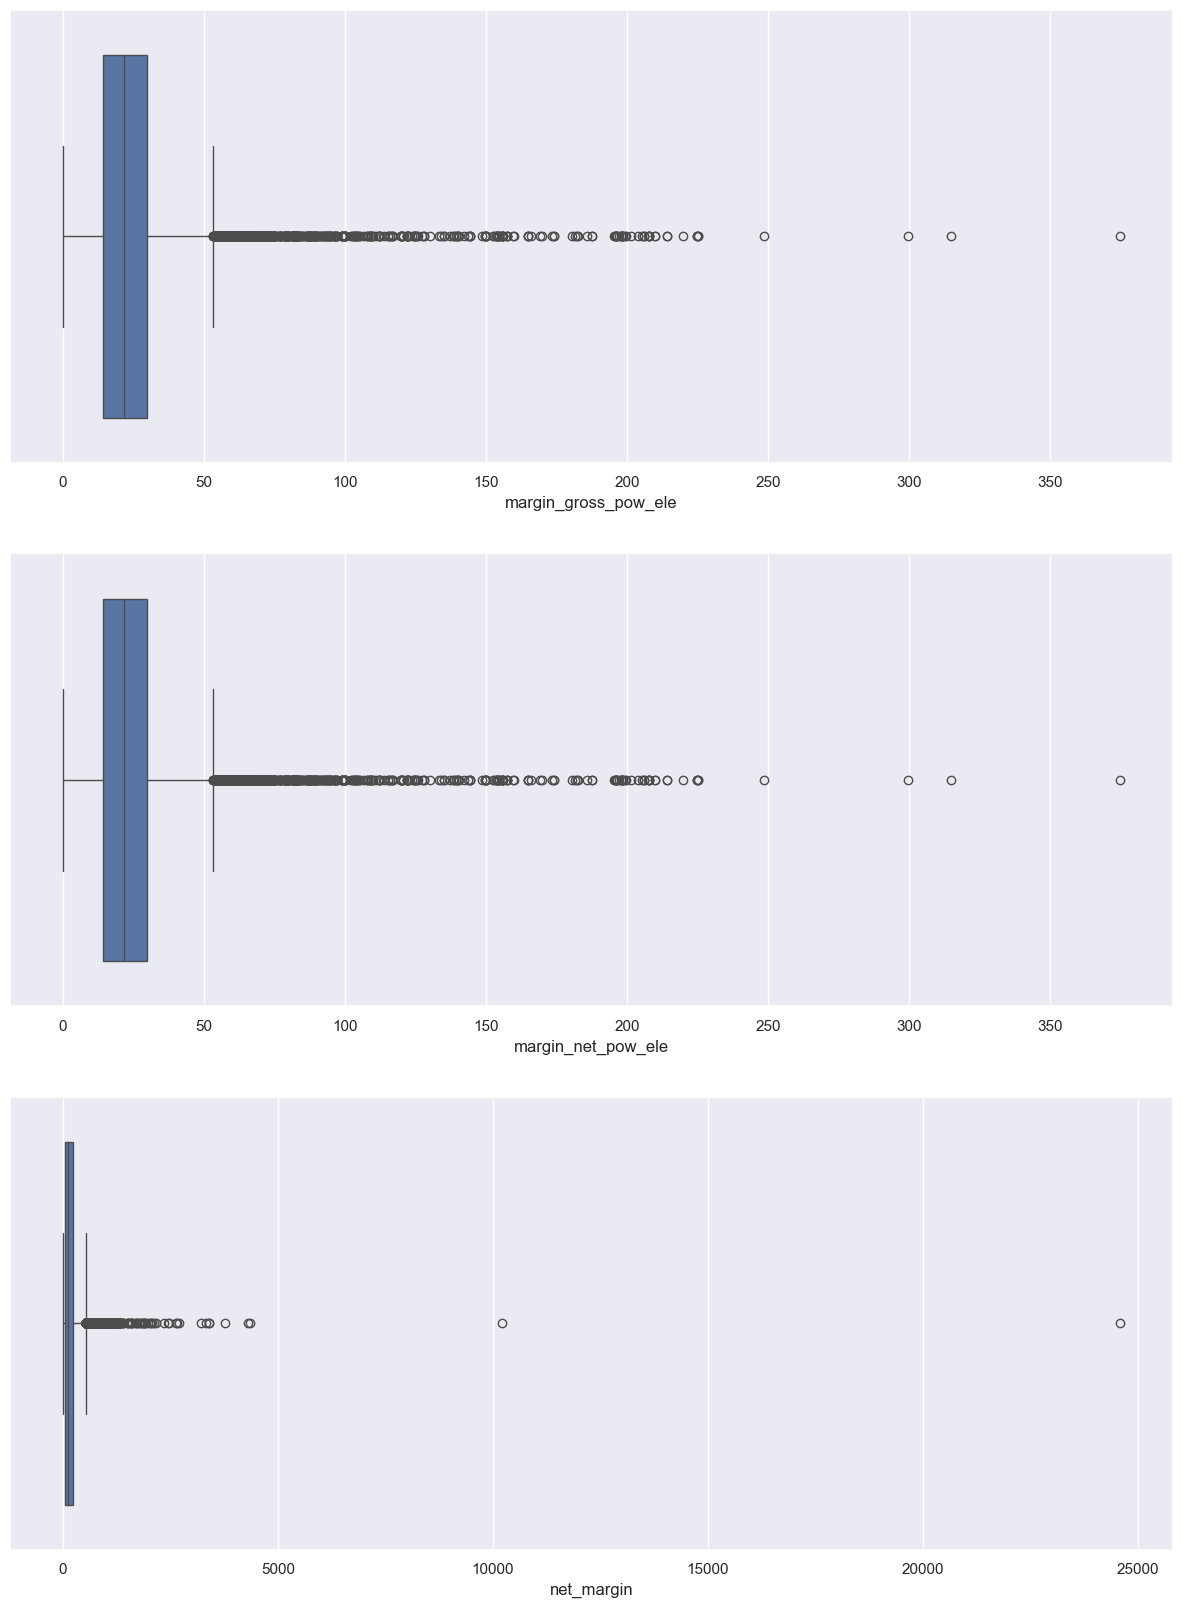

In [14]:
margin = client_data[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

fig, axs = plt.subplots(nrows=3, figsize=(15, 20))

sns.boxplot(margin['margin_gross_pow_ele'], ax=axs[0], orient='h')
sns.boxplot(margin['margin_net_pow_ele'], ax=axs[1], orient='h')
sns.boxplot(margin['net_margin'], ax=axs[2], orient='h')

for ax in axs:
    ax.ticklabel_format(style='plain', axis='x')
    plt.show()

- More outliers contained within the margin columns.

# Subscribed Power

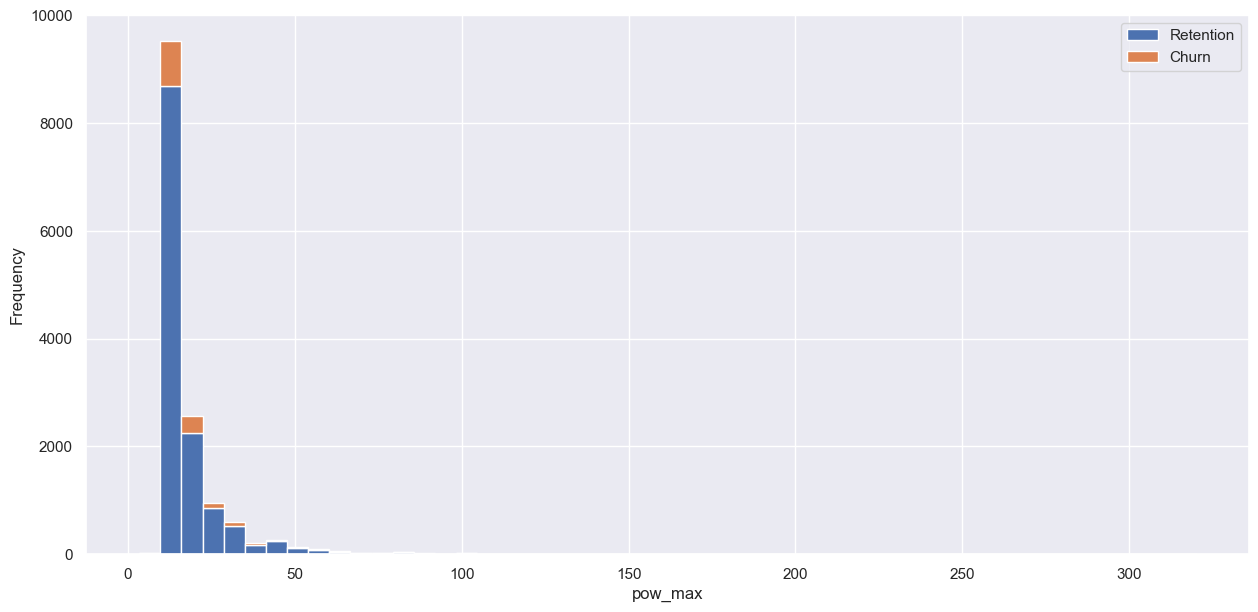

In [15]:
power = client_data[['id', 'pow_max', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(15, 7))
plot_distribution(power, 'pow_max', axs)

- Another highly positively skewed distribution with a long tail.

# Other Columns

In [ ]:
others = client_data[['id', 'nb_prod_act', 'num_years_antig', 'origin_up', 'churn']]

products = others.groupby([others["nb_prod_act"],others["churn"]])["id"].count().unstack(level=1)
products_percentage = (products.div(products.sum(axis=1), axis=0)*100).sort_values(by=[1], ascending=False)

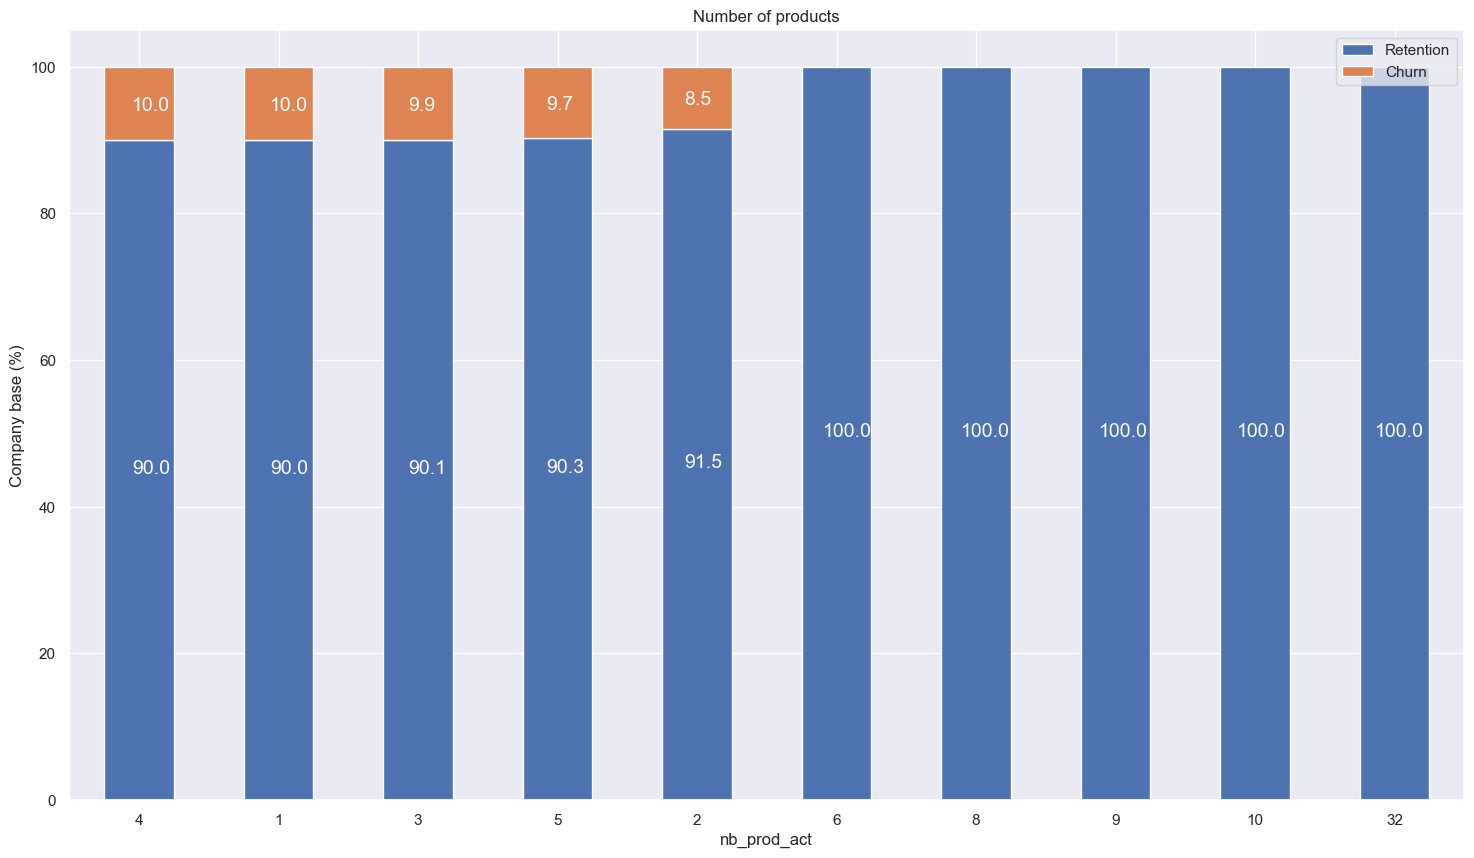

In [17]:
plot_stacked_bars(products_percentage, "Number of products")

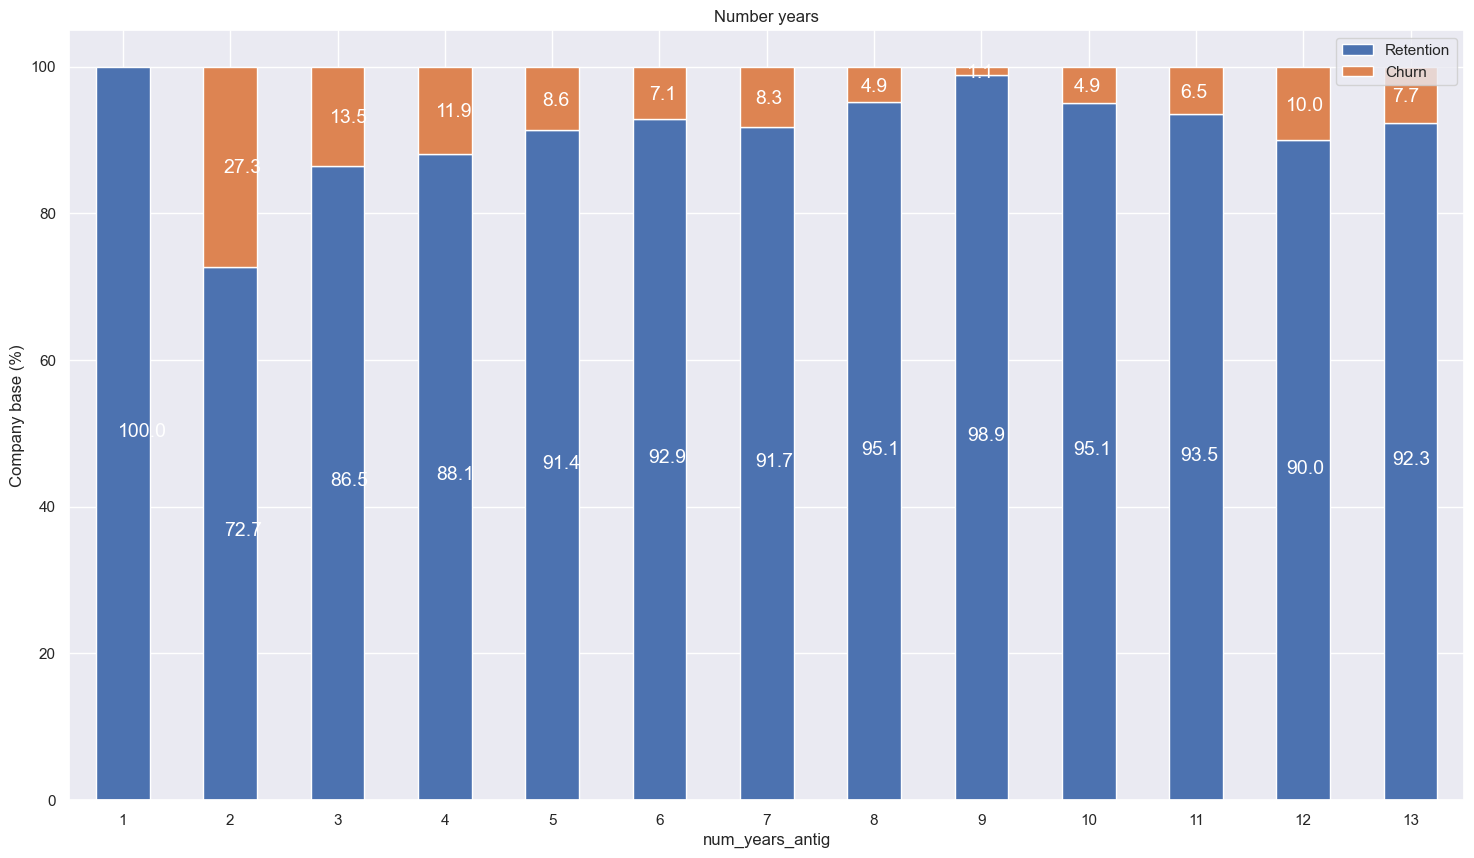

In [18]:
years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stacked_bars(years_antig_percentage, "Number years")

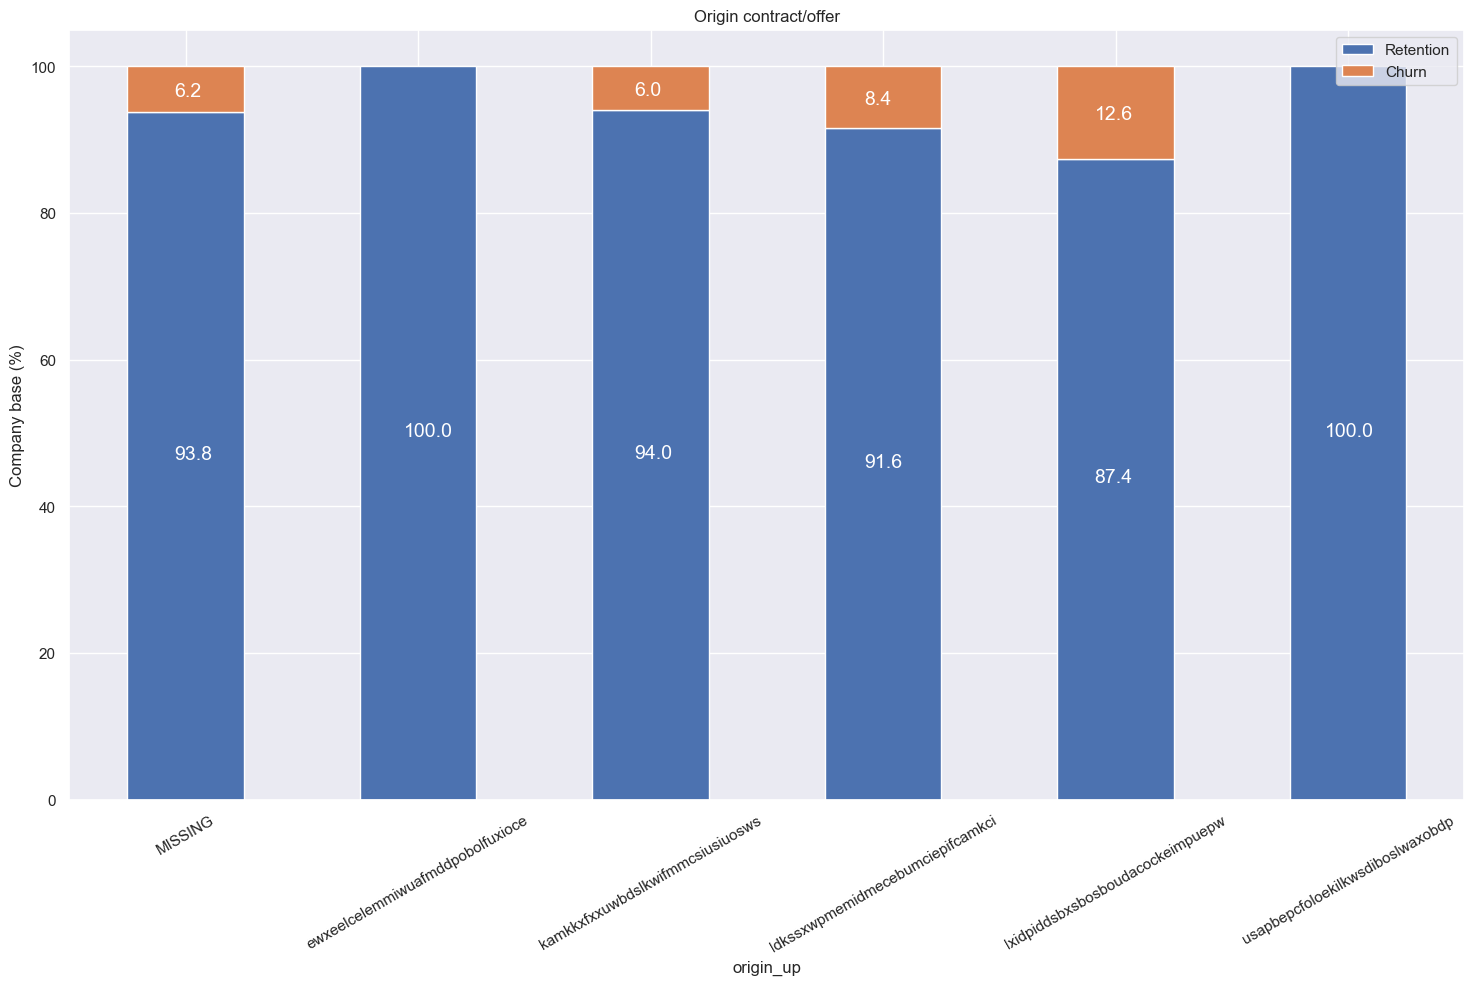

In [19]:
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer", rot_=30)

# Misc Info

In [10]:
print(f'Number of unique IDs: {price_data['id'].nunique()}')
#print(price_data['price_peak_var'].describe())
#print(price_data.head(15))

Number of unique IDs: 16096


- Price data contains **16096 unique customer id values**, 1490 more than client data
- ['price_date'] is object dtype, observations are monthly and chronological
- may need more information regarding price peaks